# Part 1: Qubits and Bayesian Statistics 101
#### *Tutorial by [Alexandra Ramôa](https://sites.google.com/view/alexandraramoa)*

## Installs and imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.special import logsumexp

In [ ]:
%%capture
!pip install qiskit
!pip install pylatexenc
!pip install qiskit_aer

In [ ]:
import qiskit

## Bayesian methods in quantum science: examples

As a framework for dealing with probabilistic phenomena, Bayesian statistics can be useful for quantum science. This includes quantum algorithms, quantum metrology, quantum sensing, among other applications.

Here are some examples:

- [Entanglement-free Heisenberg-limited phase estimation](https://arxiv.org/pdf/0709.2996)
- [Robust online Hamiltonian learning](https://iopscience.iop.org/article/10.1088/1367-2630/14/10/103013)
- [How to best sample a periodic probability distribution, or on the accuracy of Hamiltonian finding strategies](https://arxiv.org/pdf/1110.3067)
- [Online adaptive quantum characterization of a nuclear spin](https://www.nature.com/articles/s41534-021-00389-z)
- [Magnetic-Field Learning Using a Single Electronic Spin in Diamond with One-Photon Readout at Room Temperature](https://journals.aps.org/prx/pdf/10.1103/PhysRevX.9.021019)
- [Experimental Quantum Hamiltonian Learning](https://arxiv.org/pdf/1703.05402)
- [Calibration of Quantum Devices via Robust Statistical Methods](https://arxiv.org/pdf/2507.06941)
- [Bayesian Quantum Amplitude Estimation](https://arxiv.org/pdf/2412.04394)

If any of these papers paper on  catches your eye (or any other related to the topic "Bayes for Quantum"), let me know! I can prepare a "journal club" type meeting.

## 1.1 Qubits and the measurement problem

Classical bits can be in one of two states: `0` or `1`. Quantum bits, or **qubits**, can be in a superposition of states. The state $|\psi\rangle$ of a qubit can be represented in Dirac notation as:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle
$$

If we measure this state, the result is **probabilistic**, given by the Born rule: we get outcome $0$ with probability $p_0=|\alpha|^2$, and outcome $1$ with probability $p_1=|\beta|^2$. These probabilities sum to 1. The coefficients $\alpha$ and $\beta$, which are called the amplitudes of states $|0\rangle$ and $|1\rangle$ respectively, cannot be accessed directly. We can use repeated measurements to estimate them. We call these measurements the *number of shots* in an experiment. Since the shot number must be finite, the approximation is necessarily imperfect; this is called *sampling noise*.

**Quantum computing** exists because superposition and other peculiarities of quantum mechanics can be exploited for computational gain. A device exploiting quantum physics can **speed up computations** as compared to a classical computer.

However, harvesting this advantage is not straighforward. While superposition is useful, it does not allow us to directly "parallelize computations", due to the probabilistic nature of measurement. Rather, we are able to solve some problems faster by carefully coreographing quantum phenomena in a gainful way.



### 1.1.1 Quantum circuits

Quantum circuits are a possible model for quantum computation, where gates (quantum operators) act on qubits. We will start by looking at a simple quantum circuit with a single qubit, which starts in the state 0 (by default) and is acted upon by a Hadamard gate. What is the outcome distribution?

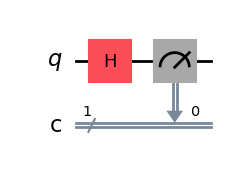

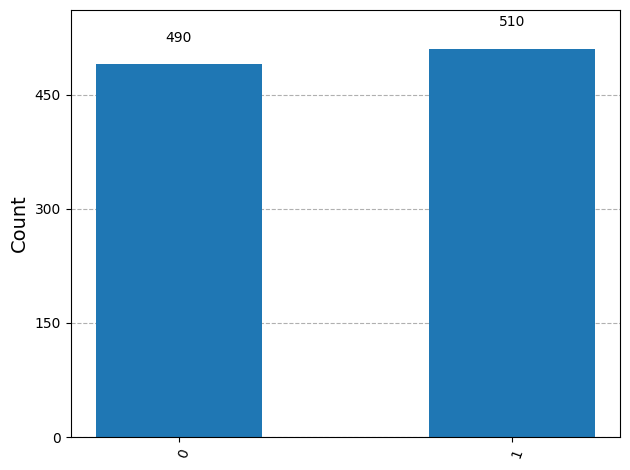

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

def measure(qc, Nshots, return_p1 = True):
    simulator = AerSimulator()
    tqc = transpile(qc, simulator)
    result = simulator.run(tqc,shots=Nshots).result()
    counts = result.get_counts()
    if return_p1:
      p1 = counts.get('1', 0)/Nshots
      return p1
    else:
      return counts

qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0, 0)
display(qc.draw('mpl'))

Nshots = 1000
counts = measure(qc, Nshots, return_p1 = False)
plot_histogram(counts)

## 1.2 Frequentist estimation of measurement probabilities

'Typical' statistics take a frequentist view of probability, where probabilities are relative frequencies. We can then approximate $p_1$ as:

$$
p_1 \approx \frac{\text{number of 1 outcomes}}{\text{total number of shots}}
$$

In [ ]:
print(f"> Estimated p_1: {counts['1']/Nshots:.4f}.")

> Estimated p_1: 0.5100.


This estimate is probabilistic; if we run the same code again, we will get different results. The `Nshots` parameter affects the estimate as well. The list `l` below

**Create a list `y` with $p_1$ for each number of shots in `l`, and plot it as a function of `l` using the `plot_p1` function defined below.**

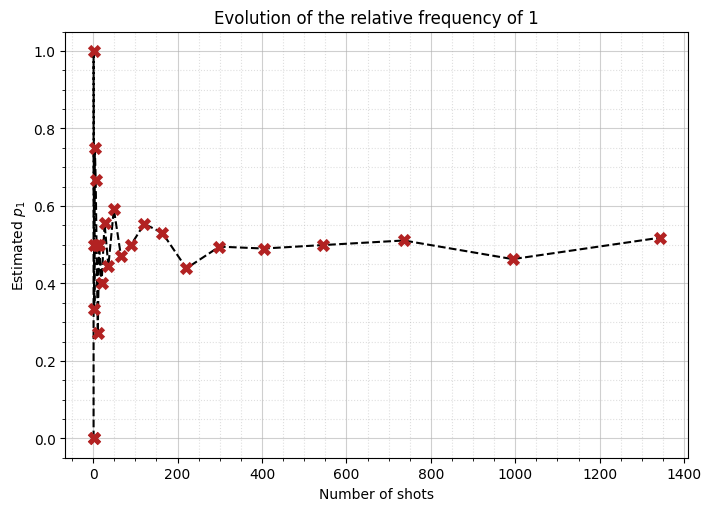

In [ ]:
def plot_p1(l, y):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    ax.set_title("Evolution of the relative frequency of 1")
    ax.plot(l, y, color="black", linestyle="--")
    ax.scatter(l, y, marker="x",s=50, zorder = 2, linewidth=3.5, color="firebrick")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Number of shots")
    ax.set_ylabel("Estimated $p_1$")

    plt.show()

# Write your code below.

### Solution:
l = [int(1.35**i) for i in range(25)]
y = [measure(qc, Nshots) for Nshots in l]

plot_p1(l, y)

What happens to the estimate of $p_1$?

### 1.2.1 Frequentist learning rate

As previously discussed, the estimate of $p_1$ has statistical variability. We now want to assess how the number of shots affects this variability. We can estimate the standard deviation in the estimate by repeating the execution a certain number of times `Nruns` for each `Nshots` in the list `l` from before.

**Create a list `stds` with the standard deviation of $p_1$ across `Nruns=10` runs for each number of shots in `l`, and plot it as a function of `l` using the `plot_std` function defined below.**

In [ ]:
def plot_std(l, y, log, ref = True):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    ax.set_title("Evolution of the standard deviation")
    ax.plot(l, y, color="black", linestyle="--")
    ax.scatter(l, y, marker="x",s=50, zorder = 2, linewidth=3.5, color="firebrick")

    if ref:
        l = np.array(l); y = np.array(y)
        # remove log(0) problems
        mask = np.isfinite(l) & np.isfinite(y) if log else (l != 0) & (y != 0)
        (m,b), _ = opt.curve_fit(lambda x, m, b: m*x+b, np.log(l[mask]), np.log(y[mask]))
        k = np.exp(b)
        f = lambda x: k*x**m
        ax.plot(l, [f(x) for x in l], alpha = 0.75, linewidth = 2, linestyle = ":", color = '0.35', label = f"O($N^{{{m:.2f}}}$)")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Number of shots")
    ax.set_ylabel("Standard deviation of $p_1$")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()

    plt.show()

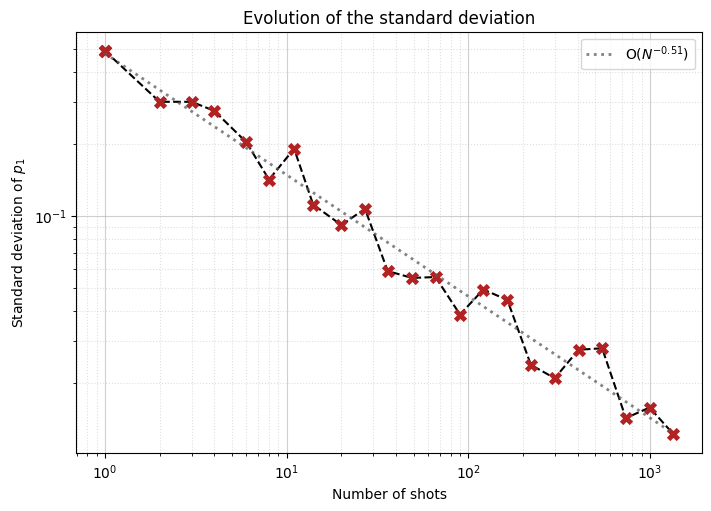

In [ ]:
# Write your code below.

### Solution:
Nruns = 10
stds = [np.std([measure(qc, Nshots) for i in range(Nruns)]) for Nshots in l]
plot_std(l, stds, log = False)

How does the standard deviation evolve as `Nshots` increases?

Note the double-logarithmic scale, which turns $f(x) = Bx^m$ into a straight line of slope $m$ and offset $\log(B)$, i.e. $\log(f(x)) = m\log(x) + \log(B)$.

## 1.3 Bayesian estimation of measurement probabilities

Bayesian statistics offer a different paradigm to think about probabilities. Instead of estimating the parameter $p_1$ as a probability, we consider the probability of $p_1$ being true, for any valid $p_1 \in [0,1]$.

This represents a probabilistic view of knowledge: rather than calculating one good estimate directly as in frequentist statistics, we assign probabilities to all possible estimates. The probability of a given value, e.g. $p_1=0.5$, is determined by how likely it would have been to produce the data we observed (if prior information is available, it can be factored in as well).

Look at the histogram we produced in section 1.1.1. Which value of $p_1$ could have produced these observations?

The answer is: **any value** in the open interval $]0,1[$. Yet, it seems obvious that e.g. $p_1 = 0.01$ is a worse guess  than $p_1 = 0.5$. This is due to the fact that the former would have been extremely unlikely to generate these measurements. While this probability is not zero, it is very low - so $p_1=0.01$ clearly seems like a poor guess.

In this case the difference is intuitive, but we can ask questions that are not as easy to answer. For instance: how much better is $p_1 = 0.5$ as compared to $p_1 = 0.01$? What's the best estimate, and its associated uncertainty?

We can answer these questions, among many others, using Bayes' theorem, which offers an analytical framework to reason about these topics. Mathematically, Bayes' rule is given by:

$$
P(p_1 \mid D) = \frac{L(p_1 \mid D)P(p_1)}{P(D)}
$$

Here $D$ is the data: an outcome (eg getting outcome $1$ a total of $600$ times in $1000$ measurements). $p_1$ is, again, the parameter we want to estimate.

- $P(p_1 \mid D)$ is called the posterior probability: it encodes our knowledge given the empirical data. This knowledge takes the form of a probability distribution quantifying the merit of each possible parameter value, which we can evaluate pointwise. Higher values mean a better guess.

- The key element in the RHS is the likelihood, defined as $L(p_1 \mid D) = P(D \mid p_1)$. The merit of a given value for $p_1$ is proportional to how likely $p_1$ would have been to generate the data we collected. We assume it to be a known generative model for the probabilistic phenomenon we are studying; in our case, it takes the simple form $L(p_1 \mid D) = p_1^{N_1}(1-p_1)^{N_0}$.

- $P(p_1)$ is the prior probability; if we do not have pre-existing knowledge about $p_1$, we assign equal probability to all possibilities in the interval $[0,1]$.

- $P(D)$ can be regarded as a normalization constant.

We now have all the tools necessary to reason in the Bayesian framework. Given a dataset $D$, like our set of binary measurements, we can evaluate $P(p_1 \mid D)$ at any value of $p_1$ to quantify its merit as an estimate of the true value.

**Calculate the posterior probability of $p_1=0.4$ and $p_1=0.5$, using the data from section 1.1.1. Which is a better guess for the true value? Quantify this superiority.**

In [ ]:
# Write your code below.

### Solution:
def posterior(p1, counts):
    N0 = counts.get('0', 0)
    N1 = counts.get('1', 0)
    return p1**N1*(1-p1)**N0

p1s = [0.4, 0.5]
Ps = [posterior(p1, counts) for p1 in p1s]
for p1, P in zip(p1s, Ps):
    print(f"> Posterior probability of {p1=}: {P:.2e}")

print(f"> Probability ratio: {Ps[1]/Ps[0]:.2e}")

> Posterior probability of p1=0.4: 2.21e-312
> Posterior probability of p1=0.5: 9.33e-302
> Probability ratio: 4.22e+10


We can evaluate the posterior distribution pointwise, but it is actually a continuous probability distribution over all possible values of $p_1$. It is not possible to represent a general continuous probability distribution exactly, but we can approximate it. The simplest way to do so is using a grid. Alternatively, one may use analytical approximations (such as a Gaussian fit), or more sophisticated numerical methods (such as Monte Carlo). Here we will use a grid for simplicity.

Below we use sweep over this grid to plot the posterior as a function of $p_1$. Notice that the multiplication of multiple small probabilities is prone to underflows. We can avoid this using logarithms, as is done below. This converts the products into sums of large negative numbers.

Remember: our goal is to get an estimator for $p_1$. We can use the mean, mode or median of the posterior distribution. The choice depends on the choice of a loss function. Here we use the mean (square loss).

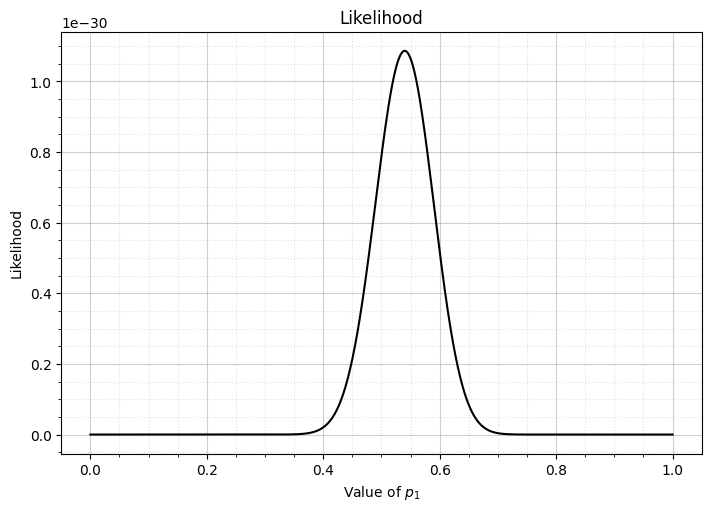

> Bayesian estimate for Nshots=100: 0.5392


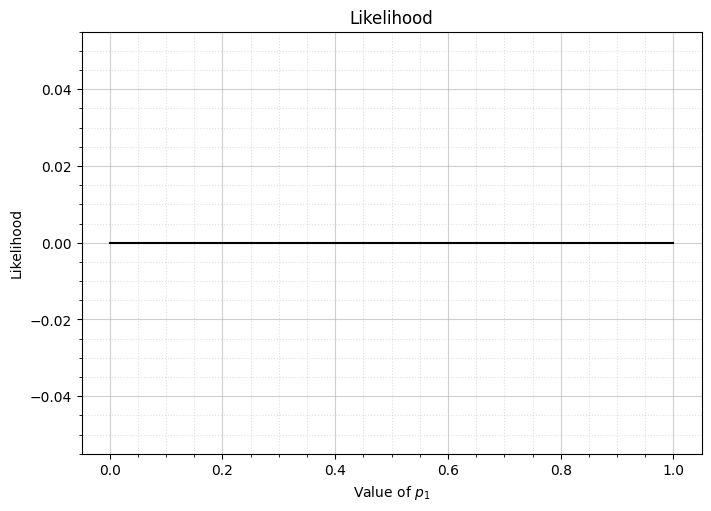

> Bayesian estimate for Nshots=1000: 0.5030


/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: divide by zero encountered in log
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))


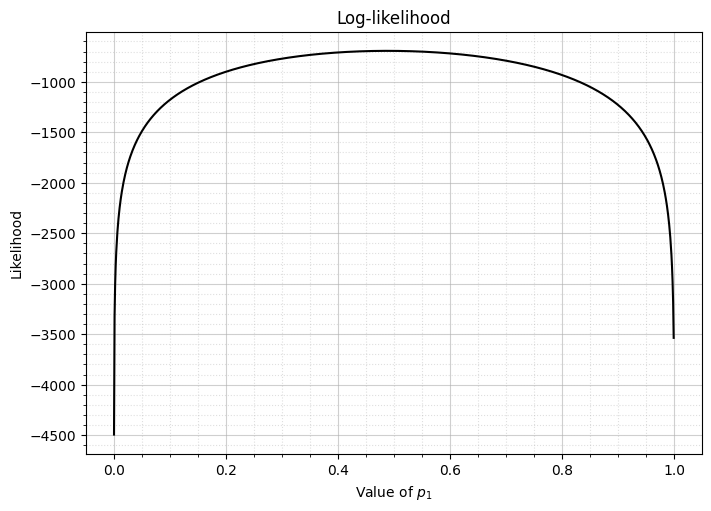

> Bayesian estimate for Nshots=1000: 0.4880


In [ ]:
def plot_likelihood(ps, Ls, log):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    ax.set_title("Log-likelihood" if log else "Likelihood")
    ax.plot(ps, Ls, color="black")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Value of $p_1$")
    ax.set_ylabel("Likelihood")

    plt.show()

def mu_std(xs, ws, return_std, log):
    if log:
        logZ = logsumexp(ws)
        w = np.exp(ws - logZ)
        mu = np.sum(w * xs)
        std = np.sqrt(np.sum(w * (xs - mu)**2))
    else:
        ws = ws/np.sum(ws)
        mu = np.sum(ws * xs)
        std = np.sqrt(np.sum(ws * (xs - mu)**2))
    if return_std:
        return mu, std
    return mu

def bayesian_estimate(qc, Nshots, Npoints = int(1e3), log = True, plot = False, std = False):
    ps = np.linspace(1e-4,1, Npoints)
    counts = measure(qc, Nshots, return_p1 = False)
    if log:
        Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))
    else:
        Ls = ps**counts.get('1',0)*(1-ps)**counts.get('0',0)
    if plot:
        plot_likelihood(ps, Ls, log)
    return mu_std(ps, Ls, std, log)

for Nshots,log in zip([100, 1000, 1000], [False, False, True]):
    r = bayesian_estimate(qc, Nshots, log = log, plot = True)
    print(f"> Bayesian estimate for {Nshots=}: {r:.4f}")

This allows us to observe the evolution of $p_1$ with `Nshots`, but now using Bayesian rather than frequentist statistics.

**Create a list `y2` with $p_1$ for each number of shots in the same `l` as before, and plot it as a function of `l` using the `plot_p1` function as before.**

/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: divide by zero encountered in log
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))
/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: invalid value encountered in multiply
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))


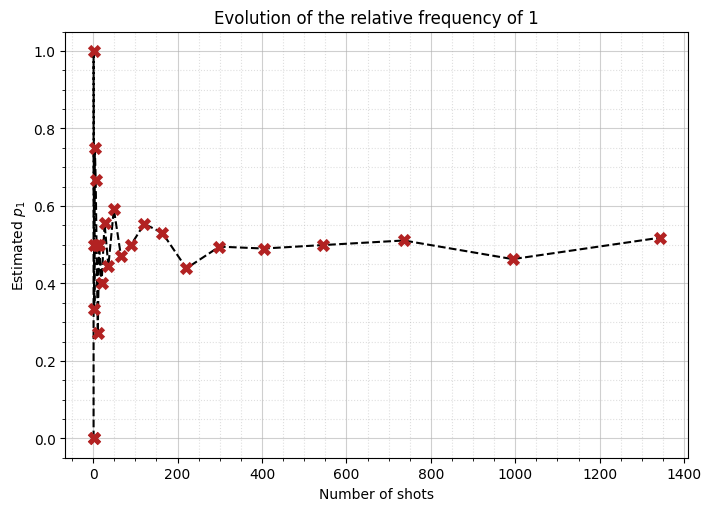

In [ ]:
# Write your code below.

### Solution:
y2 = [bayesian_estimate(qc, Nshots) for Nshots in l]
plot_p1(l, y)

### 1.3.1 Bayesian learning rate: strategy 1

**Create a list `stds2` with the standard deviation of $p_1$ across `Nruns=10` runs for each number of shots in `l`, and plot it as a function of `l` using the `plot_std` function as before.**

/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: divide by zero encountered in log
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))
/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: invalid value encountered in multiply
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))


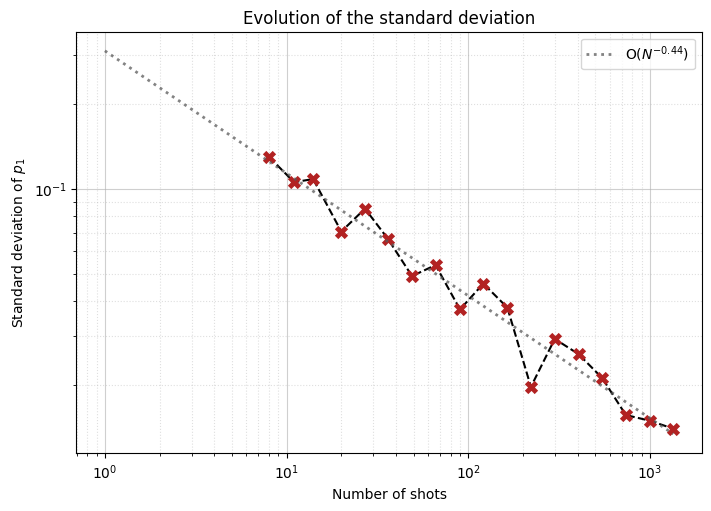

In [ ]:
# Write your code below.

### Solution:
mus = [bayesian_estimate(qc, Nshots, std = False, log = True) for i in range(Nruns)]
ws = np.array([1 for i in range(Nruns)])
stds2 = [mu_std([bayesian_estimate(qc, Nshots, std = False, log = True) for i in range(Nruns)],
                ws, return_std = True, log = True)[1]
         for Nshots in l]
#stds2 = [np.std([bayesian_estimate(qc, Nshots, log = True) for i in range(Nruns)]) for Nshots in l]
plot_std(l, stds2, log = True, ref = True)

### 1.3.2 Bayesian learning rate: strategy 2

However, now we have another way to estimate uncertainties! We can extract standard deviations directly from the Bayesian distribution.

**Create a list `stds3` with the standard deviation of $p_1$, calculated from the Bayesian distribution (use the `std` argument in the function `bayesian_estimate`) for each number of shots in `l`, and plot it as a function of `l` using the `plot_std` function as before.**

/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: divide by zero encountered in log
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))
/tmp/ipython-input-6342/2396943687.py:36: RuntimeWarning: invalid value encountered in multiply
  Ls = counts.get('1',0)*np.log(ps) + counts.get('0',0)*np.log((1-ps))


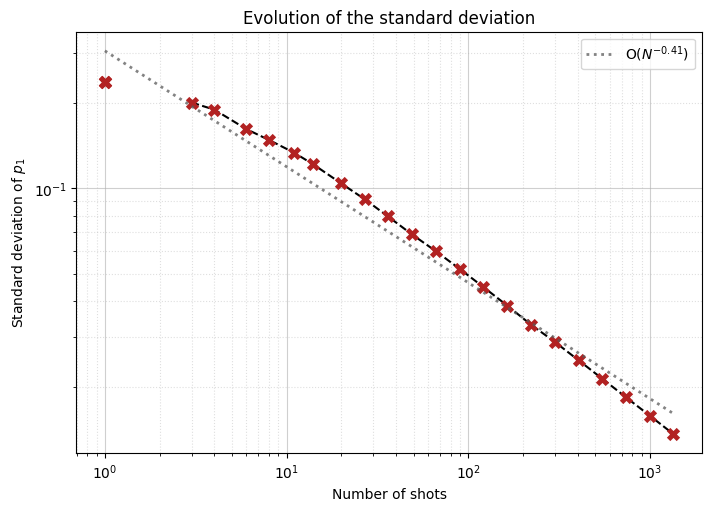

In [ ]:
# Write your code below.

### Solution:
stds3 = [bayesian_estimate(qc, Nshots, log = True, std = True)[1] for Nshots in l]
plot_std(l, stds3, log = True, ref = True)